# Annex 1: Quant Data Analysis


#### 1. Step 1 and Step 2: Identifying key features, trends, and patterns and detecting predictive or casual relationships between features using suitable mathematical and statistical techniques

In Steps 1 and 2, the dataset was systematically explored to identify key features, trends, and potential relationships. First, numeric columns were selected and their mean and standard deviation were calculated to understand the scale and dispersion of each feature. Histograms of selected columns highlighted the distribution of anonymized feature values, revealing skewness or concentration patterns. The code then quantified missing data, providing counts and percentages for each column.

Then, correlation analysis was performed on numeric features using a correlation matrix and visualized via a heatmap. Highly correlated feature pairs where $(|r| > 0.8)$ were identified, suggesting potential redundancy and informing feature selection for dimensionality reduction or modeling. PCA was applied to reduce the feature space while preserving variance, with explained variance ratios and cumulative variance guiding the choice of principal components. These PCA components were then used in KMeans clustering to identify natural groupings of data, offering insight into latent patterns across features. Finally, stationarity tests (ADF) assessed whether features exhibited consistent statistical properties over time, highlighting which features are trend-driven versus stationary.


#### 1.1 Add Imports for neccessary libraries

In [286]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
import math

#### 1.2 Load CSV data into a DataFrame
Outputs the shape and dataframe (first 5).

In [287]:
filename = "TEST_Trader_Quant_dataset.csv"

if not os.path.exists(filename):
    raise FileNotFoundError(f"File not found: {filename}")

df = pd.read_csv(filename)

print(f"Loaded: {filename}")
print(f"Shape: {df.shape}")
display(df.head())

Loaded: TEST_Trader_Quant_dataset.csv
Shape: (8688, 56)


,1,2,3,4,5,6,7,8,9,10,...,47,48,49,50,51,52,53,54,55,56
0,74.23525,124.000,23.000,149.187,7.459,7.872,257.347,77.510,86.753,0,...,15582,6.8649,44,533,201481,85873,42474,237989,69445,33461
1,74.17525,33.105,280.280,133.749,0.709,31.305,87.454,51.044,130.774,2,...,13398,6.8589,45012,63355,230732,84898,45959,155027,45111,44533
2,74.18325,375.086,323.644,170.037,3.999,25.476,168.794,72.876,270.396,2,...,12777,6.8595,27710,55091,247450,98765,43705,206995,74398,42840
3,74.17625,48.775,25.853,93.927,39.872,14.148,72.699,65.654,352.091,0,...,14498,6.8595,32364,39759,237211,95343,35553,217658,75365,53509
4,74.17125,48.774,301.886,90.637,30.003,20.829,201.224,24.241,96.640,0,...,14704,6.8583,17667,52192,236698,102647,44195,196868,74185,19152


#### 1.3 Finding Mean and Standard Deviation of Each Feature
Displays the mean and standard deviation of all 56 features

In [288]:
overall_columns = df.select_dtypes(include='number').columns
c = overall_columns

feature_stats = pd.DataFrame({
    'mean': df[c].mean(),
    'std': df[c].std()
})

display(feature_stats)

,mean,std
1,7.229859e+01,3.600288e+00
2,7.812164e+02,1.137844e+03
3,8.073243e+02,1.262210e+03
4,1.060645e+02,1.650485e+02
5,3.962810e+01,8.174697e+01
6,6.850930e+01,1.454112e+02
7,1.048161e+02,1.790935e+02
8,4.124344e+01,1.361815e+02
9,6.688497e+01,1.600939e+02
10,9.914825e-01,8.193140e-01


#### 1.4 Identifying Range of each Feature Values
Displays the plot of the value range with frequency bins for the first 6 features

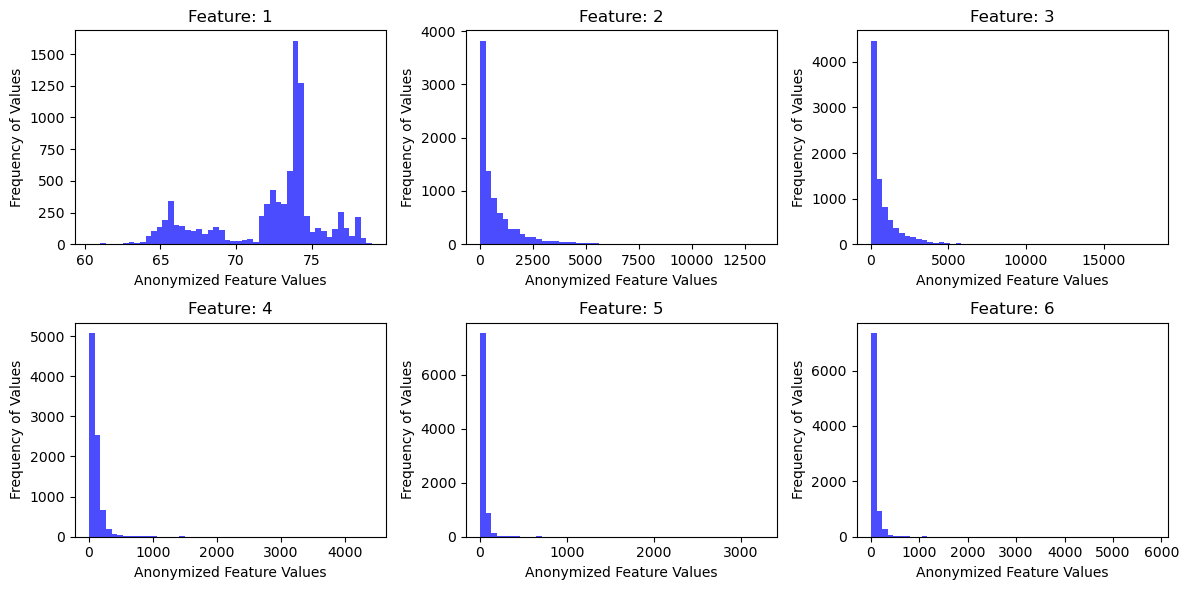

In [289]:
selected_columns = overall_columns[:6]
plt.figure(figsize=(12, 6))

for index, column in enumerate(selected_columns, 1):
    plt.subplot(2, 3, index)
    plt.hist(df[column].dropna(), bins=50, color='blue', alpha=0.7)
    plt.title(f"Feature: {column}")
    plt.xlabel('Anonymized Feature Values')
    plt.ylabel('Frequency of Values')

plt.tight_layout()
plt.show()

#### 1.5 Identify Missing Values Percentage
Displays the column counts and number of missing values in the dataset.

In [290]:
print(f"Numeric columns count: {len(overall_columns)}")

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percentage = (missing_counts / len(df)).sort_values(ascending=False)

missing_summary = pd.concat([missing_counts, missing_percentage], axis=1)
missing_summary.columns = ["missing_count", "missing_percentage"]
print ("Missing Values Summary: No Missing Values Found")


Numeric columns count: 56
Missing Values Summary: No Missing Values Found


#### 1.6 Plotting Correlation Matrix
Displays the correlation matrix between all features.

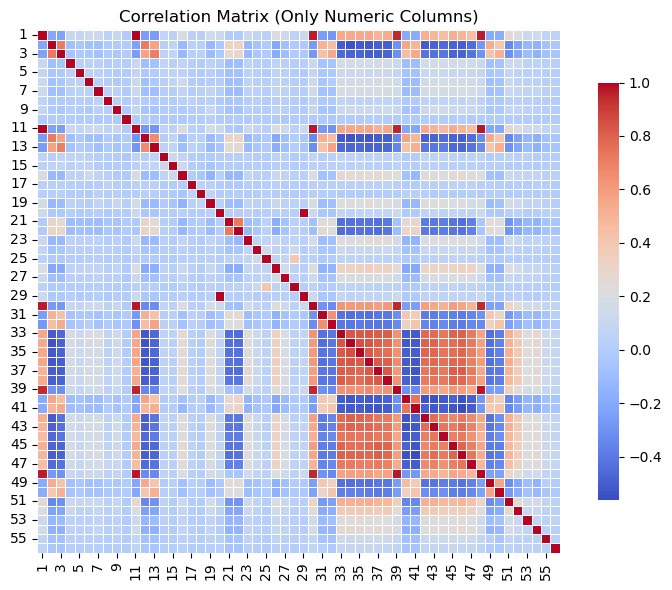

In [291]:
if len(overall_columns) > 0:
    correlation_matrix = df[overall_columns].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, linewidths=.5)
    plt.title('Correlation Matrix (Only Numeric Columns)')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found for correlation analysis.")

#### 1.7 Identifying Highly Correlated Features and Pairs
Displays the number of highly correlated feature above a threshold and shows the features we can drop in our dataset. 

In [292]:
if len(overall_columns) > 1:    
    corr_abs = correlation_matrix.abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

    threshold = 0.8
    high_corr_pairs = []

    for row in upper.columns:
        for col in upper.index:
            if row == col:
                continue
            corr_value = upper.loc[row, col]
            if corr_value > threshold:
                high_corr_pairs.append((col, row, corr_value))

    high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Correlated F1', 'Correlated F2', 'Correlation'])

    if not high_corr_df.empty:
        print("Number of Highly Correlated Feature Pairs (|r| > {}): {}".format(threshold, len(high_corr_df)))
    else:
        print("\nNo highly correlated feature pairs found above threshold of", threshold)

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    if len(to_drop) > 0:
        print(f"\nFeatures to drop due to high correlation: {to_drop}")
    else:
        print("\nNo redundant features identified for dropping.")

Number of Highly Correlated Feature Pairs (|r| > 0.8): 25

Features to drop due to high correlation: ['11', '29', '30', '34', '35', '36', '37', '38', '39', '42', '45', '46', '48']


#### 1.8 Conducting PCA Analysis to Reduce Dimensionality
Displays the top 10 principal components. The methodology standardizes all numeric features and applies PCA to extract the principal components that explain the majority of the variance in the dataset. The advantage of PCA is that it transforms correlated variables into a smaller set of uncorrelated principal component (will be used in ML later).

In [293]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[overall_columns].dropna(how='all')  
X_filled = X.fillna(X.mean())           
Xs = StandardScaler().fit_transform(X_filled)  

pca = PCA(n_components=min(20, Xs.shape[1]), random_state=42).fit(Xs)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

ev = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained))],
    'explained_variance_ratio': explained,
    'cumulative': cumulative
})

display(ev.head(10))

,PC,explained_variance_ratio,cumulative
0,PC1,0.293881,0.293881
1,PC2,0.063264,0.357145
2,PC3,0.040451,0.397596
3,PC4,0.034532,0.432128
4,PC5,0.026974,0.459101
5,PC6,0.024037,0.483138
6,PC7,0.020028,0.503166
7,PC8,0.019024,0.522190
8,PC9,0.018811,0.541001
9,PC10,0.018508,0.559509


#### 1.9 Conducting K-Means Clustering
Displays the top 20 features for each cluster. The methodology applies K-Means clustering on the first five principal components obtained from PCA to group similar data points into three distinct clusters. This approach helps identify hidden patterns or natural groupings within the data without prior labels. The advantage of K-Means clustering is that it simplifies complex datasets by grouping observations with similar characteristics

In [294]:
from sklearn.cluster import KMeans
pca_components = pca.transform(Xs)[:, :5] 

kmeans = KMeans(n_clusters=3, random_state=42).fit(pca_components)
labels = kmeans.labels_  

clustered = X_filled.copy().reset_index(drop=True) 
clustered['cluster'] = labels  

cluster_profiles = clustered.groupby('cluster').mean().T  
display(cluster_profiles.head(20))  

cluster,0,1,2
1,73.605418,66.741381,75.940506
2,277.028669,1413.983500,1510.313238
3,276.068569,1505.356878,1531.370220
4,132.386037,64.138933,80.557607
5,48.997493,23.269812,32.574486
6,90.618259,29.951363,51.804596
7,136.437260,52.764774,76.552598
8,48.913502,27.356548,36.168929
9,86.109977,34.877262,50.211890
10,0.992952,0.999082,0.976021


#### 1.10 Conducting Augmented Dickey Fuller
Displays the features that are non-stationary based on the Augmented Dickey-Fuller (ADF) test. The methodology applies the ADF test to each numeric feature in the dataset with sufficient length, calculating a p-value to determine whether the feature exhibits stationarity or contains a trend. Features with a p-value greater than 0.05 are considered non-stationary, indicating the presence of trends or time-dependent patterns.

In [295]:
from statsmodels.tsa.stattools import adfuller
print("\n=== Stationarity & Trend Detection (ADF Test) ===")

trend_results = []

for column in overall_columns:
    series = df[column].dropna().astype(float)

    if len(series) > 100:
        adf_p_value = adfuller(series, autolag='AIC')[1]
        trend_results.append((column, adf_p_value))

trend_df = pd.DataFrame(trend_results, columns=['feature', 'adf_pvalue'])

trend_df['stationary'] = trend_df['adf_pvalue'] < 0.05


selected_columns = ['feature', 'adf_pvalue', 'stationary']
stationary_rows = trend_df[trend_df['stationary'] == False][selected_columns]
display(stationary_rows)


=== Stationarity & Trend Detection (ADF Test) ===


,feature,adf_pvalue,stationary
0,1,0.934038,False
10,11,0.862729,False
29,30,0.785872,False
33,34,0.083727,False
34,35,0.133749,False
36,37,0.054701,False
38,39,0.819668,False
45,46,0.103727,False
47,48,0.716658,False


## 2. Step 3: Machine Learning and Deep Learning

In this analysis, machine learning models were used to uncover meaningful patterns and make predictions from the dataset. First, the data was prepared by identifying a potential time column and filling missing values with column means. Numeric features were standardized and then reduced using PCA, which helped focus on the most important components while removing redundancy. Lagged features were also created to capture temporal dependencies, making the data suitable for time-aware modeling.

Several regression models, specifically, Random Forest, Gradient Boosting, Extra Trees, Ridge, Lasso, and Linear Regression, were trained to forecast the target variable. The reason why these models were selected were based on previous published efforts in modeling time series. Except Linear Regression, Lasso and Ridge, these models are able to capture non-linear trends. To compare these models' performance, RMSE and ${R^2}$ were used as metrics to provide insight into how well each model is able to capture the underlying trends in the "anonymous" dataset.

In addition, a univariate LSTM model was trained using only the "assumed" price column, taking advantage of sequential patterns over time. This approach captured complex temporal trends and non-linear relationships that simpler models might miss. By combining these methods, the analysis aims to produce accurate forecasts and identify key drivers and hidden structures in the dataset (as seen by the analysis of the best model only [2.6]). 

#### 2.1 Identify Time Data
There is no explicit time data but attemting to find one.

In [296]:
parsed_time_col = None
for c in df.columns:
    if pd.api.types.is_numeric_dtype(df[c]):
        arr = df[c].dropna().values
        if len(arr) > 3 and np.all(np.diff(arr[:100]) >= 0):
            parsed_time_col = c
            break

if parsed_time_col is None:
    print("No time column detected in original data.")
else:
    print("Using time column:", parsed_time_col)

No time column detected in original data.


#### 2.2 Create Time Data
Time Data not found so create one and set it as index.

In [297]:
df_time = df.copy().reset_index(drop=True)
df_time.index = pd.RangeIndex(start=0, stop=len(df_time))
print("No time column: using row index as time axis.")

No time column: using row index as time axis.


#### 2.3 Preparing Data for Model
Methodology standardizes all numeric features, applies PCA to reduce dimensionality, creates lagged versions of the principal components to capture temporal dependencies, and combines them with the target variable, resulting in a feature matrix.

In [298]:
numeric_cols = df_time.select_dtypes(include=np.number).columns.tolist()

target_columns = numeric_cols[0]

X = df_time[numeric_cols].fillna(df_time[numeric_cols].mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=min(20, X_scaled.shape[1]), random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, index=df_time.index, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])


lags = [1,2,3]
for col in df_pca.columns:
    for l in lags:
        df_pca[f'{col}_lag{l}'] = df_pca[col].shift(l)

df_pca[target_columns] = df_time[target_columns]
df_pca = df_pca.dropna()
print("Features shape after lagging:", df_pca.shape)

Features shape after lagging: (8685, 81)


#### 2.4 Prepare Train-Test Split
Split data for training and testing.

In [299]:
n = len(df_pca)
train_end = int(n * 0.7)
train = df_pca.iloc[:train_end]
test = df_pca.iloc[train_end:]

X_train = train.drop(columns=[target_columns])
y_train = train[target_columns]
X_test = test.drop(columns=[target_columns])
y_test = test[target_columns]

#### 2.5 ML Model: Random Forest Regressor
Displays RMSE and ${R^2}$ value. Random Forest Regressor is a supervised learning technique capable of capturing non-linear relationships in the data.

In [300]:
from sklearn.metrics import mean_squared_error, r2_score

RFR = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
RFR.fit(X_train, y_train)
pred = RFR.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
print(f"Random Forest Regressor — RMSE: {rmse:.4f}, R2: {r2:.4f}")

Random Forest Regressor — RMSE: 5.4620, R2: -1.6327


#### 2.6 ML Model: Gradient Boosting Regressor
Displays RMSE and ${R^2}$ value. Gradient Boosting Regressor is a supervised ensemble technique that sequentially builds weak learners to capture complex non-linear patterns and improve predictive accuracy.

In [301]:
gbr = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)
pred_gbr = gbr.predict(X_test)
rmse_gbr = math.sqrt(mean_squared_error(y_test, pred_gbr))
r2_gbr = r2_score(y_test, pred_gbr)
print(f"GradientBoosting — RMSE: {rmse_gbr:.4f}, R2: {r2_gbr:.4f}")

GradientBoosting — RMSE: 4.2205, R2: -0.5718


#### 2.7 ML Model: Linear Regression
Displays RMSE and ${R^2}$ value. Linear Regression is a supervised technique that models a linear relationship between features and the target variable.

In [302]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
rmse_lr = math.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)
print(f"LinearRegression — RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")

LinearRegression — RMSE: 0.8121, R2: 0.9418


#### 2.8 ML Model: ExtraTrees Regressor
Displays RMSE and ${R^2}$ value. Extra Trees Regressor is a supervised ensemble method similar to Random Forest, using randomized splits to capture non-linear relationships and reduces variance.

In [303]:
etr = ExtraTreesRegressor(n_estimators=500, random_state=42, n_jobs=-1)
etr.fit(X_train, y_train)
pred_etr = etr.predict(X_test)
rmse_etr = math.sqrt(mean_squared_error(y_test, pred_etr))
r2_etr = r2_score(y_test, pred_etr)
print(f"ExtraTrees — RMSE: {rmse_etr:.4f}, R2: {r2_etr:.4f}")

ExtraTrees — RMSE: 5.5491, R2: -1.7172


#### 2.9 ML Model: Ridge
Displays RMSE and ${R^2}$ value. Ridge Regression is a supervised linear technique with L2 regularization that reduces overfitting by shrinking coefficients while modeling linear relationships.

In [304]:
ridge = Ridge(alpha=1.0, random_state=42) 
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
rmse_ridge = math.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

print(f"Ridge Regression — RMSE: {rmse_ridge:.4f}, R2: {r2_ridge:.4f}")

Ridge Regression — RMSE: 0.8121, R2: 0.9418


#### 2.10 ML Model: Lasso
Displays RMSE and ${R^2}$ value. Lasso Regression is a supervised linear technique with L1 regularization that can shrink some coefficients to zero, performing feature selection while modeling linear relationships.

In [305]:
lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)  
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)
rmse_lasso = math.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)
print(f"Lasso Regression — RMSE: {rmse_lasso:.4f}, R2: {r2_lasso:.4f}")

Lasso Regression — RMSE: 0.8615, R2: 0.9345


## 3. Deep Learning Approach of using RNNs (Specifically LSTMs)

#### 3.1 Hyperparameters to Tune
Hyperparameters of the model that can be changed

In [315]:
time_step = 150            #number of previous timesteps to use
split = 0.8                #train-test split ratio
learning_rate = 0.001      #learning rate for optimizer
epochs = 50                #number of training epochs
batch_size_input = 1000    #batch size for training

#### 3.2 Take Relevant Data and Preprocess it
Methodology involves scaling data and creating test and train sets.

In [307]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# This code assumes df_time.columns[0] is price
price_series = df_time.iloc[:, 0].values.astype(np.float32)
time_index = np.arange(len(df_time), dtype=np.float32)
data2 = np.column_stack((time_index, price_series))

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

scaler = StandardScaler()
price_scaled = scaler.fit_transform(data2[:, 1].reshape(-1, 1))

X, y = create_sequences(price_scaled, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)
y = y.reshape(-1, 1)

train_size = int(len(X) * split)
X_train_2, X_test_2 = X[:train_size], X[train_size:]
y_train_2, y_test_2 = y[:train_size], y[train_size:]

train_dataset = TensorDataset(torch.tensor(X_train_2, dtype=torch.float32),
                              torch.tensor(y_train_2, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test_2, dtype=torch.float32),
                             torch.tensor(y_test_2, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=batch_size_input, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size_input, shuffle=False)


#### 3.3 Model Architecture for LSTM
The model consists of a 3-layer LSTM with dropout to capture sequential dependencies, followed by a ReLU-activated fully connected layer and a final linear layer for regression output. It processes input sequences and predicts the target based on the last timestep.

In [ ]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, num_layers=3, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)      
        out = self.fc(out)
        out = out[:, -1, :]  
        return out

#### 3.4 Train Model
Trains the LSTM model in training mode, performing forward passes, computing the loss, backpropagating gradients, and updating the model weights using the optimizer.

In [309]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LSTMRegressor(input_size=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model(X_batch)
        loss = criterion(out.squeeze(), y_batch.squeeze())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

Epoch 5/50, Loss: 0.0734
Epoch 10/50, Loss: 0.0498
Epoch 15/50, Loss: 0.0034
Epoch 20/50, Loss: 0.0051
Epoch 25/50, Loss: 0.0141
Epoch 30/50, Loss: 0.0078
Epoch 35/50, Loss: 0.0060
Epoch 40/50, Loss: 0.0045
Epoch 45/50, Loss: 0.0069
Epoch 50/50, Loss: 0.0054


#### 3.5 Evaluate Model
Evaluates the LSTM model by setting it into evaluation (inference) mode to make predictions on test data without updating weights.

In [314]:
model.eval()
preds, y_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        out = model(X_batch)
        preds.extend(out.squeeze().cpu().numpy())
        y_true.extend(y_batch.cpu().numpy())
rmse = math.sqrt(mean_squared_error(y_true, preds))
r2 = r2_score(y_true, preds)
print(f"LSTM — RMSE: {rmse:.4f}, R2: {r2:.4f}")

LSTM — RMSE: 0.4885, R2: -0.7482


#### 3.6 Best Model Importance and Plot 
The best model according to above is linear regression.

Shows a table of which PCA held the most importance. Also, plots the difference between actual and best model predicted.


PC2          0.402913
PC2_lag3     0.325837
PC2_lag1     0.284404
PC2_lag2     0.259707
PC1          0.211328
               ...   
PC18_lag3   -0.005338
PC18_lag1   -0.004224
PC10_lag3   -0.004176
PC18_lag2   -0.004078
PC8          0.003759
Length: 80, dtype: float64

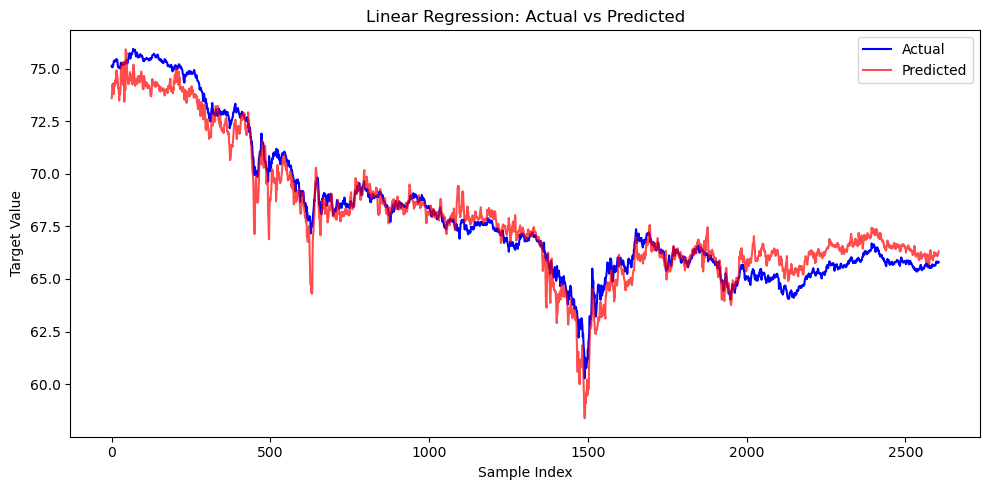

In [311]:
X_train_df = df_pca.drop(columns=[target_columns]).iloc[:train_size]
X_test_df  = df_pca.drop(columns=[target_columns]).iloc[train_size:]

importances = pd.Series(lr.coef_, index=X_train_df.columns).sort_values(key=abs, ascending=False)
display(importances)

plt.figure(figsize=(10,5))
plt.plot(y_test.reset_index(drop=True), label='Actual', color='blue')
plt.plot(pred_lr, label='Predicted', color='red', alpha=0.7)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.tight_layout()
plt.show()

#### 3.7 Results Analysis
The model performance metrics reveal a clear contrast in predictive effectiveness across the different approaches. Linear Models such as Linear Regression, Ridge and Lasso achieved the strongest results, indicating that a simple linear relationship between the selected features and the target captures most of the variability in the data. This suggests that the target variable behaves in a largely linear manner and that complex models may not add much predictive value.

In contrast, tree-based models, Random Forest, Extra Trees, and Gradient Boosting, performed poorly, with large RMSE values and negative ${R^2}$ scores, indicating that their predictions were worse than simply using the mean of the target. This could imply that the PCA-transformed components and lagged variables do not contain strong non-linear predictive signals.

The LSTM also performed poorly (but better than tree-based models), highlighting that sequential, temporal modeling does not improve accuracy for this dataset. This suggests that  that the time series is relatively stable and predictable from current values alone. Additionally, the variance of column 1 is low therefore, the LSTM is not able to capture trends effectively. Furthermore, due to a large dataset, the number of epochs is low hence, the model might be underfitting as well. Overall, the results indicate that the target variable is highly predictable with a linear approach, while more complex or non-linear models fail to provide additional insight.